# POMDP agent training — S_v2 real-cuBLAS CUDA backend

Notebook in the style of the upstream `experiments/pomdp_agent_training.ipynb`, but with an additional explicit `traincuda(...)` path for the S_v2 backend.

The original `ag.train(...)` method is not overwritten. CPU and CuPy still use the official olfactory-navigation training path; CUDA uses `ag_cuda.traincuda(...)`.


## 1. Imports and package path

Set `PACKAGE_ROOT` to the extracted S_v2 package. Keep this cell near the top, before importing `olfnav_cuda_*`, so the notebook uses this local package and not an older module from another directory.


In [1]:
from pathlib import Path
import os
import sys
import json

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

PACKAGE_ROOT = Path("/home/jlpfritas/HPC-POMDP/v1train_cuda/package_S_v2_pomdp_agent_training_style_allstates_fix3")
PACKAGE_PY = PACKAGE_ROOT / "python"

if str(PACKAGE_PY) not in sys.path:
    sys.path.insert(0, str(PACKAGE_PY))

# Avoid accidentally reusing stale modules from a previous package in the same kernel.
for name in list(sys.modules):
    if name.startswith("olfnav_cuda_backend") or name.startswith("olfnav_cuda_notebook"):
        del sys.modules[name]

from olfactory_navigation import Environment
from olfactory_navigation.agents import FSVI_Agent
from olfnav_cuda_notebook import (
    enable_cuda_backend,
    install_simulation_history_patch,
    normalize_environment_for_exact_converter,
    load_environment_from_metadata,
    read_environment_metadata,
    environment_kwargs_from_metadata,
    show_cuda_training_report,
    raw_start_points_from_environment,
    clean_start_points,
    generate_policy_start_points,
    run_policy_evaluation,
    run_policy_full_evaluation,
)

install_simulation_history_patch(verbose=True)

CUDA_LIB = PACKAGE_ROOT / "build" / "libpomdp_backup_cuda.so"
print("Using PACKAGE_ROOT:", PACKAGE_ROOT)
print("CUDA_LIB:", CUDA_LIB)
print("CUDA_LIB exists:", CUDA_LIB.exists())


[olfnav_cuda_notebook] installed non-layered SimulationHistory.plot patch
Using PACKAGE_ROOT: /home/jlpfritas/HPC-POMDP/v1train_cuda/package_S_v2_pomdp_agent_training_style_allstates_fix3
CUDA_LIB: /home/jlpfritas/HPC-POMDP/v1train_cuda/package_S_v2_pomdp_agent_training_style_allstates_fix3/build/libpomdp_backup_cuda.so
CUDA_LIB exists: True


## 2. Global configuration

Defaults are conservative. Increase `EXPANSIONS` only after a small run passes.

This notebook follows upstream `pomdp_agent_training.ipynb`: no `partitions` parameter is used. The default exact converter keeps the environment grid as the POMDP state space.

For A100, rebuild first with: `bash scripts/31_build_backend_lib.sh --arch 80 --clean`.


In [2]:
# Environment generated from the reconstructed olfactory dataset.
ENV_DIR = Path("/home/jlpfritas/HPC-POMDP/v3/recon/generated_envs_large_then_downsample_thr3e6/envs/olfnav_F_large_t1750_len768_y40_250_x450_1225_thr3e-06_maxpool_target90000_states89946_from210x775_to131x486/Env-171_526-marg_20_20_20_20-edge_wrap_vertical-start_odor_present-source_85_465_radius2")

# Training parameters.
# No PARTITIONS here: `FSVI_Agent(env)` uses all environment states, like the upstream notebook.
SEED = 123
GAMMA = 0.95
EXPANSIONS = 200
MAX_BELIEF_GROWTH = 10
PRUNE_INTERVAL = 10
PRUNE_LEVEL = 1

# CUDA backend. Use "auto_real" for S_v2 dispatch, or force "v7" / "v8".
CUDA_DEVICE = 0
CUDA_VERSION = "auto_real"

# Toggle runs.
RUN_CUDA_TRAIN = True
RUN_CPU_TRAIN = True
RUN_CUPY_TRAIN = True
RUN_POLICY_EVAL = True
# Quick evaluation subset. Set None to use all starts in the quick-eval cell.
N_EVAL = 100
# Full all-clean-starts evaluation is intentionally off by default because it can be slow.
RUN_FULL_POLICY_EVAL = True

OUT_ROOT = Path("tmp") / f"s_v2_pomdp_agent_training_allstates_fix3_e{EXPANSIONS}"
OUT_ROOT.mkdir(parents=True, exist_ok=True)
OUT_ROOT


PosixPath('tmp/s_v2_pomdp_agent_training_allstates_fix3_e200')

## 3. Load and inspect the environment

This mirrors the upstream training notebook pattern: first load/plot the environment, then create the agent.

`Environment.load(ENV_DIR)` is preferred when the environment folder already contains the metadata generated by olfactory-navigation. If that fails, the fallback constructs the environment from `data.npy` using the known source and margins.


[olfnav_cuda_notebook] loaded environment metadata: /home/jlpfritas/HPC-POMDP/v3/recon/generated_envs_large_then_downsample_thr3e6/envs/olfnav_F_large_t1750_len768_y40_250_x450_1225_thr3e-06_maxpool_target90000_states89946_from210x775_to131x486/Env-171_526-marg_20_20_20_20-edge_wrap_vertical-start_odor_present-source_85_465_radius2/METADATA.json
[olfnav_cuda_notebook] metadata data_file -> /home/jlpfritas/HPC-POMDP/v3/recon/generated_envs_large_then_downsample_thr3e6/npy/nose_data_olfnav_F_large_t1750_len768_y40_250_x450_1225_thr3e-06_maxpool_target90000_states89946_from210x775_to131x486.npy
[olfnav_cuda_notebook] Environment fallback kwargs from metadata:
  data_file=/home/jlpfritas/HPC-POMDP/v3/recon/generated_envs_large_then_downsample_thr3e6/npy/nose_data_olfnav_F_large_t1750_len768_y40_250_x450_1225_thr3e-06_maxpool_target90000_states89946_from210x775_to131x486.npy
  data_source_position=[65, 445]
  source_radius=2
  margins=[[20, 20], [20, 20]]
  boundary_condition=wrap_vertical


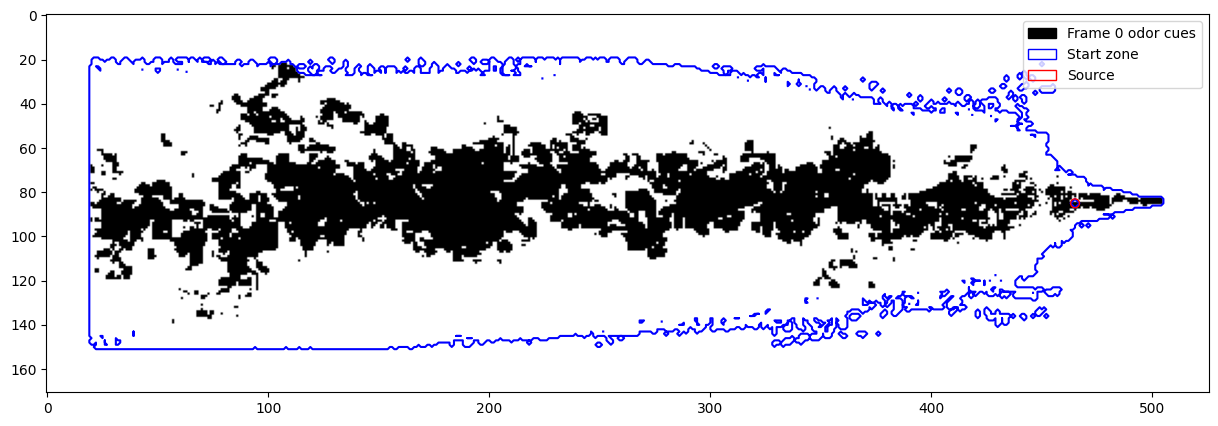

In [3]:
def load_training_environment(env_dir: Path):
    """Load env using upstream loader, with metadata-driven fallback.

    No source coordinates, margins or thresholds are hard-coded here.
    If Environment.load fails, the fallback reads the JSON metadata stored inside
    ENV_DIR and builds Environment(...) from those values.
    """
    return load_environment_from_metadata(
        env_dir,
        Environment,
        prefer_environment_load=True,
        verbose=True,
    )

# Optional audit: show which metadata file/kwargs would be used by the fallback.
try:
    env_meta = read_environment_metadata(ENV_DIR, verbose=True)
    env_kwargs_from_meta = environment_kwargs_from_metadata(ENV_DIR, env_meta, verbose=True)
except Exception as exc:
    print("Metadata audit skipped:", repr(exc))

env = load_training_environment(ENV_DIR)
normalize_environment_for_exact_converter(env, verbose=True)
print(env)
env.plot()

## 4. Agent factory

The upstream notebook uses `ag = FSVI_Agent(env)`. We keep the same semantics: no `partitions`, no `margin_partitions`, and no `minimal_converter`. This means the default exact converter uses all states of the environment.


In [4]:
def make_agent(seed=SEED):
    print(f"[MAKE_AGENT] env_path={ENV_DIR}")
    print("[MAKE_AGENT] partitions=None / all environment states")
    print(f"[MAKE_AGENT] seed={seed}")
    normalize_environment_for_exact_converter(env, verbose=False)
    return FSVI_Agent(
        env,
        seed=int(seed),
    )

# Same role as the upstream notebook cell: ag = FSVI_Agent(env)
ag = make_agent()
print("[MAKE_AGENT] model_state_count=", getattr(ag.model, "state_count", None))
print("[MAKE_AGENT] action_count=", getattr(ag.model, "action_count", None))
print("[MAKE_AGENT] observation_count=", getattr(ag.model, "observation_count", None))
ag


[MAKE_AGENT] env_path=/home/jlpfritas/HPC-POMDP/v3/recon/generated_envs_large_then_downsample_thr3e6/envs/olfnav_F_large_t1750_len768_y40_250_x450_1225_thr3e-06_maxpool_target90000_states89946_from210x775_to131x486/Env-171_526-marg_20_20_20_20-edge_wrap_vertical-start_odor_present-source_85_465_radius2
[MAKE_AGENT] partitions=None / all environment states
[MAKE_AGENT] seed=123
[MAKE_AGENT] model_state_count= 89946
[MAKE_AGENT] action_count= 4
[MAKE_AGENT] observation_count= 3


## 5. S_v2 CUDA training with `traincuda`

This is the added path. It does not replace `ag.train(...)`; it wraps the normal agent and only replaces the expensive backup stage with S_v2 real-cuBLAS CUDA backup.


In [5]:
if RUN_CUDA_TRAIN:
    if not CUDA_LIB.exists():
        raise FileNotFoundError(f"Missing CUDA_LIB={CUDA_LIB}. Build with: bash scripts/31_build_backend_lib.sh --arch 80 --clean")

    ag_cuda_base = make_agent()
    ag_cuda = enable_cuda_backend(
        ag_cuda_base,
        device=CUDA_DEVICE,
        version=CUDA_VERSION,
        gamma=GAMMA,
        lib_path=CUDA_LIB,
    )

    print("traincuda available:", hasattr(ag_cuda, "traincuda"))
    print("CUDA config:", ag_cuda._cuda_backend_config if hasattr(ag_cuda, "_cuda_backend_config") else {
        "lib_path": str(CUDA_LIB),
        "device": CUDA_DEVICE,
        "version": CUDA_VERSION,
        "gamma": GAMMA,
    })

    res_cuda = ag_cuda.traincuda(
        expansions=EXPANSIONS,
        use_gpu=True,
        gamma=GAMMA,
        max_belief_growth=MAX_BELIEF_GROWTH,
        prune_interval=PRUNE_INTERVAL,
        prune_level=PRUNE_LEVEL,
        outdir=str(OUT_ROOT / "cuda_traincuda"),
        checkpoint_every=max(1, EXPANSIONS // 4),
        visual=True,
        display_rows=12,
    )

    print(json.dumps(res_cuda.summary, indent=2))
    df_cuda = pd.DataFrame(res_cuda.rows)
else:
    ag_cuda = None
    res_cuda = None
    df_cuda = pd.DataFrame()
    print("CUDA training skipped")


[MAKE_AGENT] env_path=/home/jlpfritas/HPC-POMDP/v3/recon/generated_envs_large_then_downsample_thr3e6/envs/olfnav_F_large_t1750_len768_y40_250_x450_1225_thr3e-06_maxpool_target90000_states89946_from210x775_to131x486/Env-171_526-marg_20_20_20_20-edge_wrap_vertical-start_odor_present-source_85_465_radius2
[MAKE_AGENT] partitions=None / all environment states
[MAKE_AGENT] seed=123
traincuda available: True
CUDA config: {'lib_path': '/home/jlpfritas/HPC-POMDP/v1train_cuda/package_S_v2_pomdp_agent_training_style_allstates_fix3/build/libpomdp_backup_cuda.so', 'device': 0, 'version': 'auto_real', 'gamma': 0.95}
CUDA traincuda summary
  completed: True
  requested_expansions: 200
  completed_expansions: 200
  cuda_version_requested: auto_real
  total_wall_s: 1111.287205182016
  sum_expand_ms: 635.2525036782026
  sum_backup_ms: 32068.15212406218
  sum_update_ms: 89265.15052467585
  last_alpha_after: 1593
  last_belief_total_after: 492


,iter,nB,nG_in,actual_version,expand_ms,backup_ms,backup_wall_ms,update_ms,iter_total_ms,alpha_after,belief_total_after,pruned
188,189,10,1491,v4_sparse_precompute,1.528053,310.637100,310.817141,1043.672604,2313.452655,1500,479,False
189,190,10,1500,v4_sparse_precompute,5.104361,303.896444,304.058872,917.971231,2255.962949,1507,482,False
190,191,10,1507,v4_sparse_precompute,5.745135,316.887816,317.088325,1094.000950,2276.292184,1511,485,True
191,192,10,1511,v4_sparse_precompute,1.560092,306.747209,306.959702,1078.584364,2390.627407,1521,485,False
192,193,10,1521,v4_sparse_precompute,3.472852,323.350441,323.553594,955.054170,2294.649145,1531,486,False
193,194,10,1531,v4_sparse_precompute,4.267707,308.598954,308.800541,1101.916853,2300.470447,1540,488,False
194,195,10,1540,v4_sparse_precompute,1.580555,327.790525,328.020697,1106.172580,2454.922544,1549,488,False
195,196,10,1549,v4_sparse_precompute,1.535956,317.596678,317.807360,983.900884,2316.113872,1555,488,False
196,197,10,1555,v4_sparse_precompute,6.156588,326.920178,327.134965,1021.990072,2275.722312,1565,492,False
197,198,10,1565,v4_sparse_precompute,1.552576,320.025360,320.188802,1226.124477,2462.033829,1574,492,False


{
  "mode": "s_v2_real_cublas_traincuda_notebook",
  "completed": true,
  "requested_expansions": 200,
  "completed_expansions": 200,
  "cuda_lib_path": "/home/jlpfritas/HPC-POMDP/v1train_cuda/package_S_v2_pomdp_agent_training_style_allstates_fix3/build/libpomdp_backup_cuda.so",
  "cuda_version_requested": "auto_real",
  "real_cublas_v7v8_pipeline": true,
  "cuda_device_visible": "0",
  "gamma": 0.95,
  "max_belief_growth": 10,
  "prune_interval": 10,
  "prune_level": 1,
  "compact_cuda_backup_before_append": true,
  "use_gpu_argument_accepted_for_compatibility": true,
  "mdp_use_gpu": false,
  "policy_ms": 519.4248296320438,
  "total_wall_s": 1111.287205182016,
  "sum_expand_ms": 635.2525036782026,
  "sum_backup_ms": 32068.15212406218,
  "sum_backup_wall_ms": 32091.11414849758,
  "sum_update_ms": 89265.15052467585,
  "sum_iter_total_ms": 209476.9867490977,
  "last_alpha_after": 1593,
  "last_belief_total_after": 492
}


In [6]:
CUDA_VERSION = "v7"


ag_cuda_base = make_agent()
ag_cuda_v7 = enable_cuda_backend(
        ag_cuda_base,
        device=CUDA_DEVICE,
        version=CUDA_VERSION,
        gamma=GAMMA,
        lib_path=CUDA_LIB,
    )
    
print("traincuda available:", hasattr(ag_cuda_v7, "traincuda"))
print("CUDA config:", ag_cuda_v7._cuda_backend_config if hasattr(ag_cuda_v7, "_cuda_backend_config") else {
        "lib_path": str(CUDA_LIB),
        "device": CUDA_DEVICE,
        "version": CUDA_VERSION,
        "gamma": GAMMA,
    })
res_cuda_v7 = ag_cuda_v7.traincuda(
        expansions=EXPANSIONS,
        use_gpu=True,
        gamma=GAMMA,
        max_belief_growth=MAX_BELIEF_GROWTH,
        prune_interval=PRUNE_INTERVAL,
        prune_level=PRUNE_LEVEL,
        outdir=str(OUT_ROOT / "cuda_traincuda"),
        checkpoint_every=max(1, EXPANSIONS // 4),
        visual=True,
        display_rows=12,
    )

print(json.dumps(res_cuda_v7.summary, indent=2))
df_cuda_v7 = pd.DataFrame(res_cuda_v7.rows)
df_cuda_v7 = pd.DataFrame()
print("CUDA training skipped")

[MAKE_AGENT] env_path=/home/jlpfritas/HPC-POMDP/v3/recon/generated_envs_large_then_downsample_thr3e6/envs/olfnav_F_large_t1750_len768_y40_250_x450_1225_thr3e-06_maxpool_target90000_states89946_from210x775_to131x486/Env-171_526-marg_20_20_20_20-edge_wrap_vertical-start_odor_present-source_85_465_radius2
[MAKE_AGENT] partitions=None / all environment states
[MAKE_AGENT] seed=123
traincuda available: True
CUDA config: {'lib_path': '/home/jlpfritas/HPC-POMDP/v1train_cuda/package_S_v2_pomdp_agent_training_style_allstates_fix3/build/libpomdp_backup_cuda.so', 'device': 0, 'version': 'v7', 'gamma': 0.95}
CUDA traincuda summary
  completed: True
  requested_expansions: 200
  completed_expansions: 200
  cuda_version_requested: v7
  total_wall_s: 698.728559056297
  sum_expand_ms: 898.0443477630615
  sum_backup_ms: 31957.69391581416
  sum_update_ms: 89074.07641597092
  last_alpha_after: 1593
  last_belief_total_after: 492


,iter,nB,nG_in,actual_version,expand_ms,backup_ms,backup_wall_ms,update_ms,iter_total_ms,alpha_after,belief_total_after,pruned
188,189,10,1491,v7_cublas_all,1.919836,318.369286,318.567714,999.479713,2002.032628,1500,479,False
189,190,10,1500,v7_cublas_all,5.939817,313.151017,313.431410,1304.751467,2935.043344,1507,482,False
190,191,10,1507,v7_cublas_all,5.594322,330.304218,330.560712,867.704486,2347.656818,1511,485,True
191,192,10,1511,v7_cublas_all,1.594411,329.396594,329.590913,1300.890230,2326.090029,1521,485,False
192,193,10,1521,v7_cublas_all,4.818296,357.017638,357.191756,1267.119575,3237.887761,1531,486,False
193,194,10,1531,v7_cublas_all,5.151292,327.860614,328.044035,774.902472,2241.943080,1540,488,False
194,195,10,1540,v7_cublas_all,1.667354,352.168158,352.476221,1168.686453,2072.180836,1549,488,False
195,196,10,1549,v7_cublas_all,2.654038,328.913093,329.303706,923.077345,1784.705997,1555,488,False
196,197,10,1555,v7_cublas_all,8.885508,339.346688,339.491505,781.034276,1629.819782,1565,492,False
197,198,10,1565,v7_cublas_all,1.217665,323.362542,323.504258,776.672034,1598.208513,1574,492,False


{
  "mode": "s_v2_real_cublas_traincuda_notebook",
  "completed": true,
  "requested_expansions": 200,
  "completed_expansions": 200,
  "cuda_lib_path": "/home/jlpfritas/HPC-POMDP/v1train_cuda/package_S_v2_pomdp_agent_training_style_allstates_fix3/build/libpomdp_backup_cuda.so",
  "cuda_version_requested": "v7",
  "real_cublas_v7v8_pipeline": true,
  "cuda_device_visible": "0",
  "gamma": 0.95,
  "max_belief_growth": 10,
  "prune_interval": 10,
  "prune_level": 1,
  "compact_cuda_backup_before_append": true,
  "use_gpu_argument_accepted_for_compatibility": true,
  "mdp_use_gpu": false,
  "policy_ms": 629.2409468442202,
  "total_wall_s": 698.728559056297,
  "sum_expand_ms": 898.0443477630615,
  "sum_backup_ms": 31957.69391581416,
  "sum_backup_wall_ms": 32100.66131874919,
  "sum_update_ms": 89074.07641597092,
  "sum_iter_total_ms": 207663.50676864386,
  "last_alpha_after": 1593,
  "last_belief_total_after": 492
}
CUDA training skipped


In [7]:
CUDA_VERSION = "v8"


ag_cuda_base = make_agent()
ag_cuda_v8 = enable_cuda_backend(
        ag_cuda_base,
        device=CUDA_DEVICE,
        version=CUDA_VERSION,
        gamma=GAMMA,
        lib_path=CUDA_LIB,
    )
    
print("traincuda available:", hasattr(ag_cuda_v8, "traincuda"))
print("CUDA config:", ag_cuda_v8._cuda_backend_config if hasattr(ag_cuda_v8, "_cuda_backend_config") else {
        "lib_path": str(CUDA_LIB),
        "device": CUDA_DEVICE,
        "version": CUDA_VERSION,
        "gamma": GAMMA,
    })
res_cuda_v8 = ag_cuda_v8.traincuda(
        expansions=EXPANSIONS,
        use_gpu=True,
        gamma=GAMMA,
        max_belief_growth=MAX_BELIEF_GROWTH,
        prune_interval=PRUNE_INTERVAL,
        prune_level=PRUNE_LEVEL,
        outdir=str(OUT_ROOT / "cuda_traincuda"),
        checkpoint_every=max(1, EXPANSIONS // 4),
        visual=True,
        display_rows=12,
    )

print(json.dumps(res_cuda_v8.summary, indent=2))
df_cuda_v8 = pd.DataFrame(res_cuda_v8.rows)
df_cuda_v8 = pd.DataFrame()
print("CUDA training skipped")

[MAKE_AGENT] env_path=/home/jlpfritas/HPC-POMDP/v3/recon/generated_envs_large_then_downsample_thr3e6/envs/olfnav_F_large_t1750_len768_y40_250_x450_1225_thr3e-06_maxpool_target90000_states89946_from210x775_to131x486/Env-171_526-marg_20_20_20_20-edge_wrap_vertical-start_odor_present-source_85_465_radius2
[MAKE_AGENT] partitions=None / all environment states
[MAKE_AGENT] seed=123
traincuda available: True
CUDA config: {'lib_path': '/home/jlpfritas/HPC-POMDP/v1train_cuda/package_S_v2_pomdp_agent_training_style_allstates_fix3/build/libpomdp_backup_cuda.so', 'device': 0, 'version': 'v8', 'gamma': 0.95}
CUDA traincuda summary
  completed: True
  requested_expansions: 200
  completed_expansions: 200
  cuda_version_requested: v8
  total_wall_s: 758.8408614136279
  sum_expand_ms: 631.7434832453728
  sum_backup_ms: 26919.400464743376
  sum_update_ms: 149810.28525717556
  last_alpha_after: 1593
  last_belief_total_after: 492


,iter,nB,nG_in,actual_version,expand_ms,backup_ms,backup_wall_ms,update_ms,iter_total_ms,alpha_after,belief_total_after,pruned
188,189,10,1491,v8_cublas_by_action,1.527555,256.016083,256.178800,881.129203,2311.489569,1500,479,False
189,190,10,1500,v8_cublas_by_action,6.660573,247.805575,247.966457,1239.720300,2194.801403,1507,482,False
190,191,10,1507,v8_cublas_by_action,5.885525,264.493102,264.641287,1401.527118,2762.038108,1511,485,True
191,192,10,1511,v8_cublas_by_action,1.450999,257.037126,257.204685,862.484636,2277.309496,1521,485,False
192,193,10,1521,v8_cublas_by_action,3.522320,265.705872,265.876967,1321.928762,2296.609888,1531,486,False
193,194,10,1531,v8_cublas_by_action,5.128799,270.765359,270.901363,1220.725128,2683.133632,1540,488,False
194,195,10,1540,v8_cublas_by_action,1.408823,261.391018,261.562789,1058.873517,2353.466479,1549,488,False
195,196,10,1549,v8_cublas_by_action,1.442175,270.603789,270.764144,1346.726388,2473.542631,1555,488,False
196,197,10,1555,v8_cublas_by_action,6.705865,270.640209,270.821974,1249.863889,2685.610572,1565,492,False
197,198,10,1565,v8_cublas_by_action,1.466662,266.224544,266.393106,1078.559328,2381.588051,1574,492,False


{
  "mode": "s_v2_real_cublas_traincuda_notebook",
  "completed": true,
  "requested_expansions": 200,
  "completed_expansions": 200,
  "cuda_lib_path": "/home/jlpfritas/HPC-POMDP/v1train_cuda/package_S_v2_pomdp_agent_training_style_allstates_fix3/build/libpomdp_backup_cuda.so",
  "cuda_version_requested": "v8",
  "real_cublas_v7v8_pipeline": true,
  "cuda_device_visible": "0",
  "gamma": 0.95,
  "max_belief_growth": 10,
  "prune_interval": 10,
  "prune_level": 1,
  "compact_cuda_backup_before_append": true,
  "use_gpu_argument_accepted_for_compatibility": true,
  "mdp_use_gpu": false,
  "policy_ms": 554.6155944466591,
  "total_wall_s": 758.8408614136279,
  "sum_expand_ms": 631.7434832453728,
  "sum_backup_ms": 26919.400464743376,
  "sum_backup_wall_ms": 26953.595902770758,
  "sum_update_ms": 149810.28525717556,
  "sum_iter_total_ms": 239253.34114022553,
  "last_alpha_after": 1593,
  "last_belief_total_after": 492
}
CUDA training skipped


## 6. Optional upstream CPU training

This remains the official `olfactory_navigation` path.


In [8]:
if RUN_CPU_TRAIN:
    ag_cpu = make_agent()
    hist_cpu_train = ag_cpu.train(
        expansions=EXPANSIONS,
        max_belief_growth=MAX_BELIEF_GROWTH,
        prune_interval=PRUNE_INTERVAL,
        prune_level=PRUNE_LEVEL,
        gamma=GAMMA,
        use_gpu=False,
        overwrite_training=True,
        print_progress=True,
        print_stats=True,
    )
    print(hist_cpu_train.summary if hasattr(hist_cpu_train, "summary") else hist_cpu_train)
else:
    ag_cpu = None
    hist_cpu_train = None
    print("CPU/native training skipped")


[MAKE_AGENT] env_path=/home/jlpfritas/HPC-POMDP/v3/recon/generated_envs_large_then_downsample_thr3e6/envs/olfnav_F_large_t1750_len768_y40_250_x450_1225_thr3e-06_maxpool_target90000_states89946_from210x775_to131x486/Env-171_526-marg_20_20_20_20-edge_wrap_vertical-start_odor_present-source_85_465_radius2
[MAKE_AGENT] partitions=None / all environment states
[MAKE_AGENT] seed=123
[05/17/2026, 16:59:16] MDP_policy, not provided. Solving MDP with Value Iteration...


  0%|          | 0/1000 [00:00<?, ?it/s]

Summary of Value Iteration run
  - Model: 89946-state, 4-action
  - Converged in 212 iterations and 0.5992 seconds
  - Took on average 0.0028s per iteration


Expansions:   0%|          | 0/200 [00:00<?, ?it/s]

Summary of Point Based Value Iteration run
  - Model: 89946 state, 4 action, 3 observations
  - Converged or stopped after 200 expansion steps and 200 backup steps.
  - Resulting value function has 1580 alpha vectors.
  - Converged in 1786.5141s

  - Expand function took on average 0.0054s and yielded on average 304.28 beliefs per iteration. (0.0000s/it/belief)
  - Backup function took on average 8.9271s and yielded on average 7.88 alpha vectors per iteration. (0.0115s/it/alpha)
  - Pruning function took on average 0.0000s and yielded on average prunings of 0.00 alpha vectors per iteration.
Summary of Point Based Value Iteration run
  - Model: 89946 state, 4 action, 3 observations
  - Converged or stopped after 200 expansion steps and 200 backup steps.
  - Resulting value function has 1580 alpha vectors.
  - Converged in 1786.5141s

  - Expand function took on average 0.0054s and yielded on average 304.28 beliefs per iteration. (0.0000s/it/belief)
  - Backup function took on average 8.

## 7. Optional upstream CuPy training

Use this only when you want to compare with the original `use_gpu=True` path. On large environments this path can consume much more RAM/VRAM than the S_v2 backend.


In [15]:
if RUN_CUPY_TRAIN:
    ag_cupy = make_agent()
    hist_cupy_train = ag_cupy.train(
        expansions=EXPANSIONS,
        max_belief_growth=MAX_BELIEF_GROWTH,
        prune_interval=PRUNE_INTERVAL,
        prune_level=PRUNE_LEVEL,
        gamma=GAMMA,
        use_gpu=True,
        overwrite_training=True,
        print_progress=True,
        print_stats=True,
    )
    print(hist_cupy_train.summary if hasattr(hist_cupy_train, "summary") else hist_cupy_train)
else:
    ag_cupy = None
    hist_cupy_train = None
    print("CuPy/native GPU training skipped")


[MAKE_AGENT] env_path=/home/jlpfritas/HPC-POMDP/v3/recon/generated_envs_large_then_downsample_thr3e6/envs/olfnav_F_large_t1750_len768_y40_250_x450_1225_thr3e-06_maxpool_target90000_states89946_from210x775_to131x486/Env-171_526-marg_20_20_20_20-edge_wrap_vertical-start_odor_present-source_85_465_radius2
[MAKE_AGENT] partitions=None / all environment states
[MAKE_AGENT] seed=123
[05/17/2026, 18:00:45] MDP_policy, not provided. Solving MDP with Value Iteration...
[05/17/2026, 18:00:45] Sending Model to GPU...
[05/17/2026, 18:00:45]     > Done in 0.344s


  0%|          | 0/1000 [00:00<?, ?it/s]

Summary of Value Iteration run
  - Model: 89946-state, 4-action
  - Converged in 212 iterations and 0.6832 seconds
  - Took on average 0.0032s per iteration


Expansions:   0%|          | 0/200 [00:00<?, ?it/s]

Memory full: Out of memory allocating 9,299,697,152 bytes (allocated so far: 30,287,347,712 bytes).
Returning value function and history as is...

Summary of Point Based Value Iteration run
  - Model: 89946 state, 4 action, 3 observations
  - Converged or stopped after 137 expansion steps and 136 backup steps.
  - Resulting value function has 1077 alpha vectors.
  - Converged in 15.1516s

  - Expand function took on average 0.0083s and yielded on average 234.72 beliefs per iteration. (0.0002s/it/belief)
  - Backup function took on average 0.1031s and yielded on average 7.89 alpha vectors per iteration. (0.0025s/it/alpha)
  - Pruning function took on average 0.0000s and yielded on average prunings of 0.00 alpha vectors per iteration.
Summary of Point Based Value Iteration run
  - Model: 89946 state, 4 action, 3 observations
  - Converged or stopped after 137 expansion steps and 136 backup steps.
  - Resulting value function has 1077 alpha vectors.
  - Converged in 15.1516s

  - Expand f

## 8. Inspect S_v2 CUDA training rows

`actual_version` tells you whether S_v2 dispatched to `v7_cublas_all` or `v8_cublas_by_action`.


In [9]:
if res_cuda_v7 is not None:
    show_cuda_training_report(res_cuda_v7, display_rows=20)
    display_cols = [c for c in [
        "iter", "nB", "nG_in", "actual_version", "expand_ms", "backup_ms",
        "backup_wall_ms", "update_ms", "iter_total_ms", "alpha_after",
        "belief_total_after", "pruned"
    ] if c in df_cuda_v7.columns]
    display(df_cuda_v7[display_cols].tail(20))
else:
    print("No CUDA result available")


CUDA traincuda summary
  completed: True
  requested_expansions: 200
  completed_expansions: 200
  cuda_version_requested: v7
  total_wall_s: 698.728559056297
  sum_expand_ms: 898.0443477630615
  sum_backup_ms: 31957.69391581416
  sum_update_ms: 89074.07641597092
  last_alpha_after: 1593
  last_belief_total_after: 492


,iter,nB,nG_in,actual_version,expand_ms,backup_ms,backup_wall_ms,update_ms,iter_total_ms,alpha_after,belief_total_after,pruned
180,181,10,1421,v7_cublas_all,1.522254,305.412967,305.616632,1084.816538,2229.642682,1430,467,True
181,182,10,1430,v7_cublas_all,1.555001,293.064330,293.247454,965.180425,2376.351761,1439,467,False
182,183,10,1439,v7_cublas_all,1.497230,304.794919,305.002153,964.263158,2147.432515,1447,467,False
183,184,10,1447,v7_cublas_all,1.670569,295.261635,295.467766,1117.136337,2292.264953,1455,467,False
184,185,10,1455,v7_cublas_all,1.490954,312.663840,312.860098,992.762923,2336.962815,1464,467,False
185,186,10,1464,v7_cublas_all,8.295834,291.188398,291.367590,916.295672,2135.170933,1473,473,False
186,187,10,1473,v7_cublas_all,5.807616,336.117806,336.389977,1007.823402,2108.144941,1481,477,False
187,188,10,1481,v7_cublas_all,5.604725,296.278197,296.524376,866.825981,1648.551442,1491,479,False
188,189,10,1491,v7_cublas_all,1.919836,318.369286,318.567714,999.479713,2002.032628,1500,479,False
189,190,10,1500,v7_cublas_all,5.939817,313.151017,313.431410,1304.751467,2935.043344,1507,482,False


""


In [10]:
if res_cuda_v8 is not None:
    show_cuda_training_report(res_cuda_v8, display_rows=20)
    display_cols = [c for c in [
        "iter", "nB", "nG_in", "actual_version", "expand_ms", "backup_ms",
        "backup_wall_ms", "update_ms", "iter_total_ms", "alpha_after",
        "belief_total_after", "pruned"
    ] if c in df_cuda_v8.columns]
    display(df_cuda_v8[display_cols].tail(20))
else:
    print("No CUDA result available")

CUDA traincuda summary
  completed: True
  requested_expansions: 200
  completed_expansions: 200
  cuda_version_requested: v8
  total_wall_s: 758.8408614136279
  sum_expand_ms: 631.7434832453728
  sum_backup_ms: 26919.400464743376
  sum_update_ms: 149810.28525717556
  last_alpha_after: 1593
  last_belief_total_after: 492


,iter,nB,nG_in,actual_version,expand_ms,backup_ms,backup_wall_ms,update_ms,iter_total_ms,alpha_after,belief_total_after,pruned
180,181,10,1421,v8_cublas_by_action,1.442241,256.748332,256.909931,1728.900403,2650.474710,1430,467,True
181,182,10,1430,v8_cublas_by_action,1.531735,251.791384,251.939904,1495.003356,2982.196046,1439,467,False
182,183,10,1439,v8_cublas_by_action,1.466630,250.813536,250.965277,839.902613,2117.052255,1447,467,False
183,184,10,1447,v8_cublas_by_action,1.421006,256.050382,256.211584,1254.958101,2188.461814,1455,467,False
184,185,10,1455,v8_cublas_by_action,1.417559,261.705127,261.856396,1340.290634,2698.162161,1464,467,False
185,186,10,1464,v8_cublas_by_action,8.671617,236.922070,237.060815,938.551832,2403.306326,1473,473,False
186,187,10,1473,v8_cublas_by_action,5.539294,247.529071,247.714521,1309.759004,2275.989477,1481,477,False
187,188,10,1481,v8_cublas_by_action,4.585512,256.821528,256.981200,1346.525962,2705.236604,1491,479,False
188,189,10,1491,v8_cublas_by_action,1.527555,256.016083,256.178800,881.129203,2311.489569,1500,479,False
189,190,10,1500,v8_cublas_by_action,6.660573,247.805575,247.966457,1239.720300,2194.801403,1507,482,False


""


## 9. Generate policy start points

This cell creates shared start sets for CUDA, CPU and CuPy. It avoids hard-coded source coordinates and reads the starts from the loaded environment / agent metadata.

Generated objects:

- `start_points_raw`: raw coordinates from `env.start_probabilities > 0`
- `start_points_full`: all clean valid start points
- `start_points_eval`: subset controlled by `N_EVAL`


In [16]:
# ============================================================
# START POINTS GENERATION
# ============================================================
# The reference agent can be CUDA, CPU, CuPy or the initial ag.
# The helper returns raw/full/eval arrays and saves them under OUT_ROOT.
# ============================================================

def _native_if_cuda(agent):
    if agent is None:
        return None
    return getattr(agent, "native_agent", agent)

# Pick the first available trained/reference agent.
ref_agent = None
for candidate_name in ["ag_cuda_v7", "ag_cuda_v8","ag_cuda_base", "ag_cpu", "ag_cupy", "ag"]:
    candidate = globals().get(candidate_name, None)
    candidate = _native_if_cuda(candidate)
    if candidate is not None:
        ref_agent = candidate
        print(f"[START_POINTS] Using reference agent: {candidate_name}")
        break

if ref_agent is None:
    raise RuntimeError("No reference agent found. Create at least one agent first.")

start_point_sets = generate_policy_start_points(
    ref_agent,
    n_eval=N_EVAL,
    out_root=OUT_ROOT,
    remove_source_points=True,
    verbose=True,
)

start_points_raw = start_point_sets["raw"]
start_points_full = start_point_sets["full"]
start_points_eval = start_point_sets["eval"]

print("[START_POINTS] start_points_raw:", start_points_raw.shape)
print("[START_POINTS] start_points_full:", start_points_full.shape)
print("[START_POINTS] start_points_eval:", start_points_eval.shape)


[START_POINTS] Using reference agent: ag_cuda_v7
[START_POINTS] start_probabilities shape: (171, 526)
[START_POINTS] raw start points: (50472, 2)
[START_POINTS] clean/full start points: (50472, 2)
[START_POINTS] n_eval: 100
[START_POINTS] eval start points: (100, 2)
[START_POINTS] first eval points:
[[20 21]
 [20 22]
 [20 23]
 [20 29]
 [20 30]]
[START_POINTS] saved to: tmp/s_v2_pomdp_agent_training_allstates_fix3_e200
[START_POINTS] start_points_raw: (50472, 2)
[START_POINTS] start_points_full: (50472, 2)
[START_POINTS] start_points_eval: (100, 2)


## 10. Quick policy evaluation: CUDA / CPU / CuPy

Uses `start_points_eval`, so the three policies are tested on the same start set.

`use_gpu=False` is intentional here: the policy is already trained; this avoids mixing policy quality with simulator CPU/CuPy execution differences.

In [17]:
# ============================================================
# QUICK POLICY EVALUATION: CUDA vs CPU vs CuPy
# ============================================================

def _print_hist_summary(label, hist):
    print("\n" + "=" * 80)
    print(label)
    print("=" * 80)
    if hist is None:
        print("None")
    elif hasattr(hist, "summary"):
        print(hist.summary)
    else:
        print(hist)

COMMON_EVAL_KWARGS = dict(
    start_points=start_points_eval,
    n=len(start_points_eval),
    horizon=1000,
    reward_discount=GAMMA,
    use_gpu=False,
    time_shift=False,
    time_loop=False,
    print_progress=True,
    print_stats=True,
)

if RUN_POLICY_EVAL and res_cuda is not None:
    hist_cuda_eval = run_policy_evaluation(
        ag_cuda.native_agent,
        **COMMON_EVAL_KWARGS,
    )
    _print_hist_summary("CUDA policy evaluation", hist_cuda_eval)
else:
    hist_cuda_eval = None
    print("CUDA policy evaluation skipped")
if RUN_POLICY_EVAL and res_cuda_v7 is not None:
    hist_cuda_eval_v7 = run_policy_evaluation(
        ag_cuda_v7.native_agent,
        **COMMON_EVAL_KWARGS,
    )
    _print_hist_summary("CUDA policy evaluation", hist_cuda_eval_v7)
else:
    hist_cuda_eval_v7 = None
    print("CUDA policy evaluation skipped")

if RUN_POLICY_EVAL and res_cuda_v8 is not None:
    hist_cuda_eval_v8 = run_policy_evaluation(
        ag_cuda_v8.native_agent,
        **COMMON_EVAL_KWARGS,
    )
    _print_hist_summary("CUDA policy evaluation", hist_cuda_eval_v8)
else:
    hist_cuda_eval_v8 = None
    print("CUDA policy evaluation skipped")
if RUN_POLICY_EVAL and globals().get("hist_cpu_train", None) is not None and globals().get("ag_cpu", None) is not None:
    hist_cpu_eval = run_policy_evaluation(
        ag_cpu,
        **COMMON_EVAL_KWARGS,
    )
    _print_hist_summary("CPU/native policy evaluation", hist_cpu_eval)
else:
    hist_cpu_eval = None
    print("CPU/native policy evaluation skipped")

if RUN_POLICY_EVAL and globals().get("hist_cupy_train", None) is not None and globals().get("ag_cupy", None) is not None:
    hist_cupy_eval = run_policy_evaluation(
        ag_cupy,
        **COMMON_EVAL_KWARGS,
    )
    _print_hist_summary("CuPy/native GPU policy evaluation", hist_cupy_eval)
else:
    hist_cupy_eval = None
    print("CuPy/native GPU policy evaluation skipped")


  0%|          | 0/1000 [00:00<?, ?it/s]

Simulations done in 176.906s:
Simulations reached goal: 67/100 (33 failures (reached horizon: 0)) (67.00% success)
 - Average step count:                 638.230 +- 148.47 (Successful only: 574.313 +- 143.17)
 - Extra steps:                        244.450 +- 104.46 (Successful only: 196.522 +- 73.76)
 - Average discounted rewards (ADR):   0.000 +- 0.00 (Successful only: 0.000 +- 0.00)
 - Tmin/T:                             0.629 +- 0.11 (Successful only: 0.665 +- 0.08)

CUDA policy evaluation
Simulations reached goal: 67/100 (33 failures (reached horizon: 0)) (67.00% success)
 - Average step count:                 638.230 +- 148.47 (Successful only: 574.313 +- 143.17)
 - Extra steps:                        244.450 +- 104.46 (Successful only: 196.522 +- 73.76)
 - Average discounted rewards (ADR):   0.000 +- 0.00 (Successful only: 0.000 +- 0.00)
 - Tmin/T:                             0.629 +- 0.11 (Successful only: 0.665 +- 0.08)


  0%|          | 0/1000 [00:00<?, ?it/s]

Simulations done in 176.241s:
Simulations reached goal: 67/100 (33 failures (reached horizon: 0)) (67.00% success)
 - Average step count:                 638.230 +- 148.47 (Successful only: 574.313 +- 143.17)
 - Extra steps:                        244.450 +- 104.46 (Successful only: 196.522 +- 73.76)
 - Average discounted rewards (ADR):   0.000 +- 0.00 (Successful only: 0.000 +- 0.00)
 - Tmin/T:                             0.629 +- 0.11 (Successful only: 0.665 +- 0.08)

CUDA policy evaluation
Simulations reached goal: 67/100 (33 failures (reached horizon: 0)) (67.00% success)
 - Average step count:                 638.230 +- 148.47 (Successful only: 574.313 +- 143.17)
 - Extra steps:                        244.450 +- 104.46 (Successful only: 196.522 +- 73.76)
 - Average discounted rewards (ADR):   0.000 +- 0.00 (Successful only: 0.000 +- 0.00)
 - Tmin/T:                             0.629 +- 0.11 (Successful only: 0.665 +- 0.08)


  0%|          | 0/1000 [00:00<?, ?it/s]

Simulations done in 175.881s:
Simulations reached goal: 67/100 (33 failures (reached horizon: 0)) (67.00% success)
 - Average step count:                 638.230 +- 148.47 (Successful only: 574.313 +- 143.17)
 - Extra steps:                        244.450 +- 104.46 (Successful only: 196.522 +- 73.76)
 - Average discounted rewards (ADR):   0.000 +- 0.00 (Successful only: 0.000 +- 0.00)
 - Tmin/T:                             0.629 +- 0.11 (Successful only: 0.665 +- 0.08)

CUDA policy evaluation
Simulations reached goal: 67/100 (33 failures (reached horizon: 0)) (67.00% success)
 - Average step count:                 638.230 +- 148.47 (Successful only: 574.313 +- 143.17)
 - Extra steps:                        244.450 +- 104.46 (Successful only: 196.522 +- 73.76)
 - Average discounted rewards (ADR):   0.000 +- 0.00 (Successful only: 0.000 +- 0.00)
 - Tmin/T:                             0.629 +- 0.11 (Successful only: 0.665 +- 0.08)


  0%|          | 0/1000 [00:00<?, ?it/s]

Simulations done in 154.040s:
Simulations reached goal: 85/100 (15 failures (reached horizon: 0)) (85.00% success)
 - Average step count:                 583.220 +- 137.55 (Successful only: 550.612 +- 122.98)
 - Extra steps:                        189.440 +- 91.82 (Successful only: 169.824 +- 84.16)
 - Average discounted rewards (ADR):   0.000 +- 0.00 (Successful only: 0.000 +- 0.00)
 - Tmin/T:                             0.688 +- 0.12 (Successful only: 0.701 +- 0.12)

CPU/native policy evaluation
Simulations reached goal: 85/100 (15 failures (reached horizon: 0)) (85.00% success)
 - Average step count:                 583.220 +- 137.55 (Successful only: 550.612 +- 122.98)
 - Extra steps:                        189.440 +- 91.82 (Successful only: 169.824 +- 84.16)
 - Average discounted rewards (ADR):   0.000 +- 0.00 (Successful only: 0.000 +- 0.00)
 - Tmin/T:                             0.688 +- 0.12 (Successful only: 0.701 +- 0.12)


  0%|          | 0/1000 [00:00<?, ?it/s]

Simulations done in 169.216s:
Simulations reached goal: 79/100 (21 failures (reached horizon: 0)) (79.00% success)
 - Average step count:                 623.070 +- 125.36 (Successful only: 584.544 +- 113.08)
 - Extra steps:                        229.290 +- 63.93 (Successful only: 208.316 +- 45.41)
 - Average discounted rewards (ADR):   0.000 +- 0.00 (Successful only: 0.000 +- 0.00)
 - Tmin/T:                             0.631 +- 0.07 (Successful only: 0.640 +- 0.06)

CuPy/native GPU policy evaluation
Simulations reached goal: 79/100 (21 failures (reached horizon: 0)) (79.00% success)
 - Average step count:                 623.070 +- 125.36 (Successful only: 584.544 +- 113.08)
 - Extra steps:                        229.290 +- 63.93 (Successful only: 208.316 +- 45.41)
 - Average discounted rewards (ADR):   0.000 +- 0.00 (Successful only: 0.000 +- 0.00)
 - Tmin/T:                             0.631 +- 0.07 (Successful only: 0.640 +- 0.06)


## 11. Plot quick policy evaluation histories

CUDA hist.plot()
CUDA hist.plot()
CUDA hist.plot()
CPU/native hist.plot()


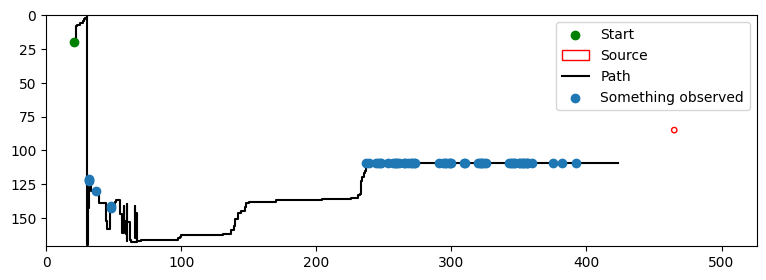

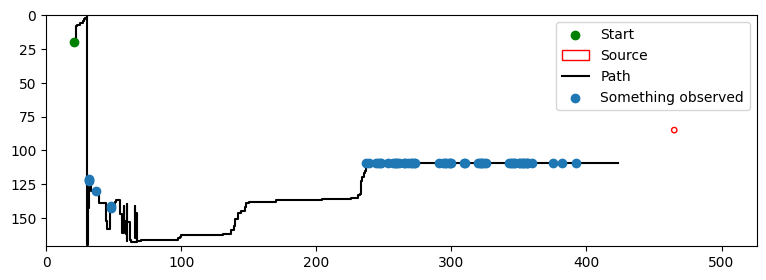

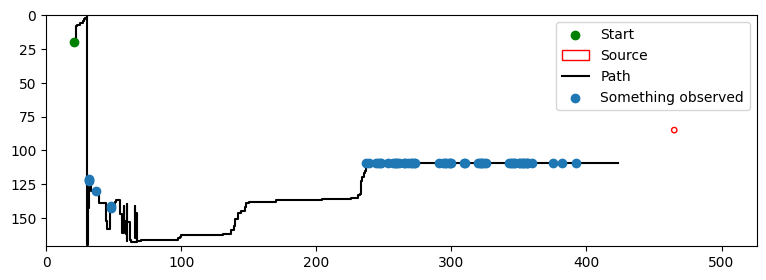

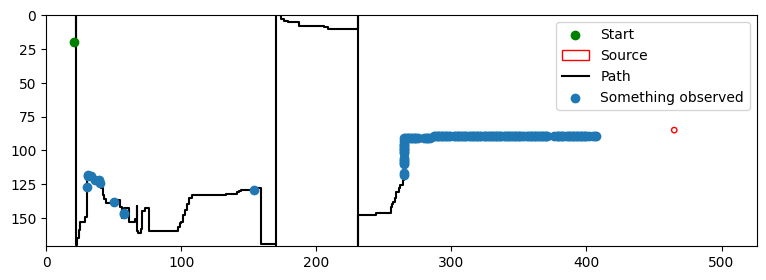

In [13]:
if hist_cuda_eval is not None:
    print("CUDA hist.plot()")
    hist_cuda_eval.plot()

if hist_cuda_eval_v7 is not None:
    print("CUDA hist.plot()")
    hist_cuda_eval_v7.plot()

if hist_cuda_eval_v8 is not None:
    print("CUDA hist.plot()")
    hist_cuda_eval_v8.plot()

if hist_cpu_eval is not None:
    print("CPU/native hist.plot()")
    hist_cpu_eval.plot()

if hist_cupy_eval is not None:
    print("CuPy/native GPU hist.plot()")
    hist_cupy_eval.plot()


## 12. Full policy evaluation: CUDA / CPU / CuPy

This uses `start_points_full`, i.e. all clean starts. It is disabled by default via `RUN_FULL_POLICY_EVAL=False` because the all-states environment can be expensive.

In [36]:
# ============================================================
# FULL POLICY EVALUATION: CUDA vs CPU vs CuPy
# ============================================================

FULL_EVAL_KWARGS = dict(
    start_points=start_points_full,
    n=len(start_points_full),
    horizon=1000,
    reward_discount=GAMMA,
    use_gpu=False,
    time_shift=False,
    time_loop=False,
    print_progress=True,
    print_stats=True,
)

print("[FULL_EVAL] start_points_full:", start_points_full.shape)

if RUN_FULL_POLICY_EVAL and res_cuda is not None:
    hist_cuda_full = run_policy_evaluation(
        ag_cuda.native_agent,
        **FULL_EVAL_KWARGS,
    )
    _print_hist_summary("CUDA FULL policy evaluation", hist_cuda_full)
else:
    hist_cuda_full = None
    print("CUDA full policy evaluation skipped")
    
if RUN_POLICY_EVAL and res_cuda_v7 is not None:
    hist_cuda_eval_v7 = run_policy_evaluation(
        ag_cuda_v7.native_agent,
        **COMMON_EVAL_KWARGS,
    )
    _print_hist_summary("CUDA policy evaluation", hist_cuda_eval_v7)
else:
    hist_cuda_eval_v7 = None
    print("CUDA policy evaluation skipped")

if RUN_POLICY_EVAL and res_cuda_v8 is not None:
    hist_cuda_eval_v8 = run_policy_evaluation(
        ag_cuda_v8.native_agent,
        **COMMON_EVAL_KWARGS,
    )
    _print_hist_summary("CUDA policy evaluation", hist_cuda_eval_v8)
else:
    hist_cuda_eval_v8 = None
    print("CUDA policy evaluation skipped")

if RUN_FULL_POLICY_EVAL and globals().get("hist_cpu_train", None) is not None and globals().get("ag_cpu", None) is not None:
    hist_cpu_full = run_policy_evaluation(
        ag_cpu,
        **FULL_EVAL_KWARGS,
    )
    _print_hist_summary("CPU/native FULL policy evaluation", hist_cpu_full)
else:
    hist_cpu_full = None
    print("CPU/native full policy evaluation skipped")

if RUN_FULL_POLICY_EVAL and globals().get("hist_cupy_train", None) is not None and globals().get("ag_cupy", None) is not None:
    hist_cupy_full = run_policy_evaluation(
        ag_cupy,
        **FULL_EVAL_KWARGS,
    )
    _print_hist_summary("CuPy/native GPU FULL policy evaluation", hist_cupy_full)
else:
    hist_cupy_full = None
    print("CuPy/native GPU full policy evaluation skipped")


[FULL_EVAL] start_points_full: (50472, 2)
CUDA full policy evaluation skipped


  0%|          | 0/1000 [00:00<?, ?it/s]

Simulations done in 121.119s:
Simulations reached goal: 67/100 (33 failures (reached horizon: 0)) (67.00% success)
 - Average step count:                 638.230 +- 148.47 (Successful only: 574.313 +- 143.17)
 - Extra steps:                        244.450 +- 104.46 (Successful only: 196.522 +- 73.76)
 - Average discounted rewards (ADR):   0.000 +- 0.00 (Successful only: 0.000 +- 0.00)
 - Tmin/T:                             0.629 +- 0.11 (Successful only: 0.665 +- 0.08)

CUDA policy evaluation
Simulations reached goal: 67/100 (33 failures (reached horizon: 0)) (67.00% success)
 - Average step count:                 638.230 +- 148.47 (Successful only: 574.313 +- 143.17)
 - Extra steps:                        244.450 +- 104.46 (Successful only: 196.522 +- 73.76)
 - Average discounted rewards (ADR):   0.000 +- 0.00 (Successful only: 0.000 +- 0.00)
 - Tmin/T:                             0.629 +- 0.11 (Successful only: 0.665 +- 0.08)


  0%|          | 0/1000 [00:00<?, ?it/s]

Simulations done in 117.958s:
Simulations reached goal: 67/100 (33 failures (reached horizon: 0)) (67.00% success)
 - Average step count:                 638.230 +- 148.47 (Successful only: 574.313 +- 143.17)
 - Extra steps:                        244.450 +- 104.46 (Successful only: 196.522 +- 73.76)
 - Average discounted rewards (ADR):   0.000 +- 0.00 (Successful only: 0.000 +- 0.00)
 - Tmin/T:                             0.629 +- 0.11 (Successful only: 0.665 +- 0.08)

CUDA policy evaluation
Simulations reached goal: 67/100 (33 failures (reached horizon: 0)) (67.00% success)
 - Average step count:                 638.230 +- 148.47 (Successful only: 574.313 +- 143.17)
 - Extra steps:                        244.450 +- 104.46 (Successful only: 196.522 +- 73.76)
 - Average discounted rewards (ADR):   0.000 +- 0.00 (Successful only: 0.000 +- 0.00)
 - Tmin/T:                             0.629 +- 0.11 (Successful only: 0.665 +- 0.08)


  0%|          | 0/1000 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 13. Plot full policy evaluation histories

CUDA FULL hist.plot()
CPU/native FULL hist.plot()
CuPy/native GPU FULL hist.plot()


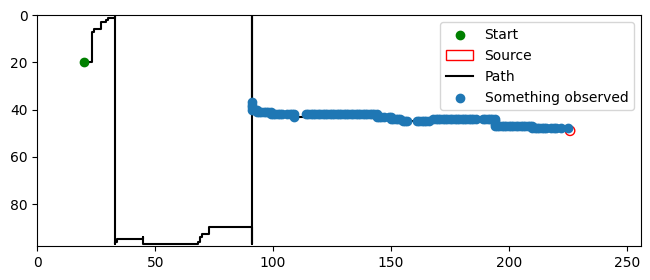

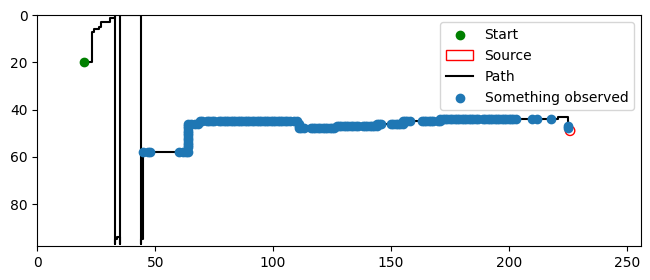

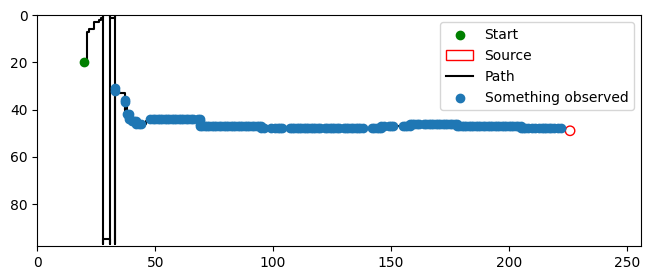

In [ ]:
if hist_cuda_full is not None:
    print("CUDA FULL hist.plot()")
    hist_cuda_full.plot()
    
if hist_cuda_eval_v7 is not None:
    print("CUDA FULL hist.plot()")
    hist_cuda_eval_v7.plot()

if hist_cuda_eval_v8 is not None:
    print("CUDA FULL hist.plot()")
    hist_cuda_eval_v8.plot()

if hist_cpu_full is not None:
    print("CPU/native FULL hist.plot()")
    hist_cpu_full.plot()

if hist_cupy_full is not None:
    print("CuPy/native GPU FULL hist.plot()")
    hist_cupy_full.plot()


## 14. Save compact run metadata

In [ ]:
metadata = {
    "package_root": str(PACKAGE_ROOT),
    "cuda_lib": str(CUDA_LIB),
    "env_dir": str(ENV_DIR),
    "state_space": "all_environment_states",
    "spacial_subdivisions": None,
    "model_state_count": getattr(getattr(ag, "model", None), "state_count", None),
    "seed": SEED,
    "gamma": GAMMA,
    "expansions": EXPANSIONS,
    "cuda_version": CUDA_VERSION,
    "n_eval": None if N_EVAL is None else int(N_EVAL),
    "n_start_points_raw": int(len(start_points_raw)) if "start_points_raw" in globals() else None,
    "n_start_points_full": int(len(start_points_full)) if "start_points_full" in globals() else None,
    "n_start_points_eval": int(len(start_points_eval)) if "start_points_eval" in globals() else None,
    "run_full_policy_eval": bool(RUN_FULL_POLICY_EVAL),
    "cuda_summary": getattr(res_cuda, "summary", None),
}
(OUT_ROOT / "notebook_run_metadata.json").write_text(json.dumps(metadata, indent=2, sort_keys=True, default=str) + "\n")
print("Saved metadata:", OUT_ROOT / "notebook_run_metadata.json")


Saved metadata: tmp/s_v2_pomdp_agent_training_allstates_fix3_e100/notebook_run_metadata.json
